# K-Means Clustering & Algorithm Comparison

**Goal:** Cluster NYC FHV pickup locations using K-Means on the same feature space as DBSCAN, then produce a quantitative side-by-side comparison.

**Data source:** `../Data/raw/merged_trip_emissions_coordinates.csv`  \n

**Features used for clustering:**
- `pickup_lat`, `pickup_lon` — geographic position
- `hour_sin`, `hour_cos` — cyclic encoding of pickup hour

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

In [ ]:
DATA_PATH = "../Data/raw/merged_trip_emissions_coordinates.csv"
SUBSET_N  = 10_000

df_full = pd.read_csv(DATA_PATH, low_memory=False)
df      = df_full.sample(n=min(SUBSET_N, len(df_full)), random_state=RANDOM_STATE).reset_index(drop=True)

df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
df["pickup_lat"]       = pd.to_numeric(df["pickup_lat"],        errors="coerce")
df["pickup_lon"]       = pd.to_numeric(df["pickup_lon"],        errors="coerce")
df["trip_miles"]       = pd.to_numeric(df["trip_miles"],        errors="coerce")
df["co2TailpipeGpm"]   = pd.to_numeric(df["co2TailpipeGpm"],    errors="coerce")
df["co2_total_g"]      = pd.to_numeric(df["co2_total_g"],       errors="coerce")

df = df.dropna(subset=["pickup_lat", "pickup_lon", "pickup_datetime", "PULocationID"])
print(f"Full dataset : {len(df_full):,} rows")
print(f"Working subset: {len(df):,} rows")

Full dataset : 2,062,185 rows
Working subset: 10,000 rows


## Feature Engineering

In [3]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour

df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

features = ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]
scaler   = StandardScaler()
X        = scaler.fit_transform(df[features].values)

print(f"Feature matrix shape: {X.shape}")
pd.DataFrame(X, columns=features).describe().round(3)

Feature matrix shape: (10000, 4)


,pickup_lat,pickup_lon,hour_sin,hour_cos
count,10000.000,10000.000,10000.000,10000.000
mean,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000
min,-3.298,-4.227,-1.275,-1.657
25%,-0.698,-0.776,-0.852,-0.938
50%,-0.041,-0.194,-0.205,0.154
75%,0.535,0.457,0.890,1.028
max,2.628,3.821,1.611,1.220


## Elbow Method + Silhouette Scores to Choose K

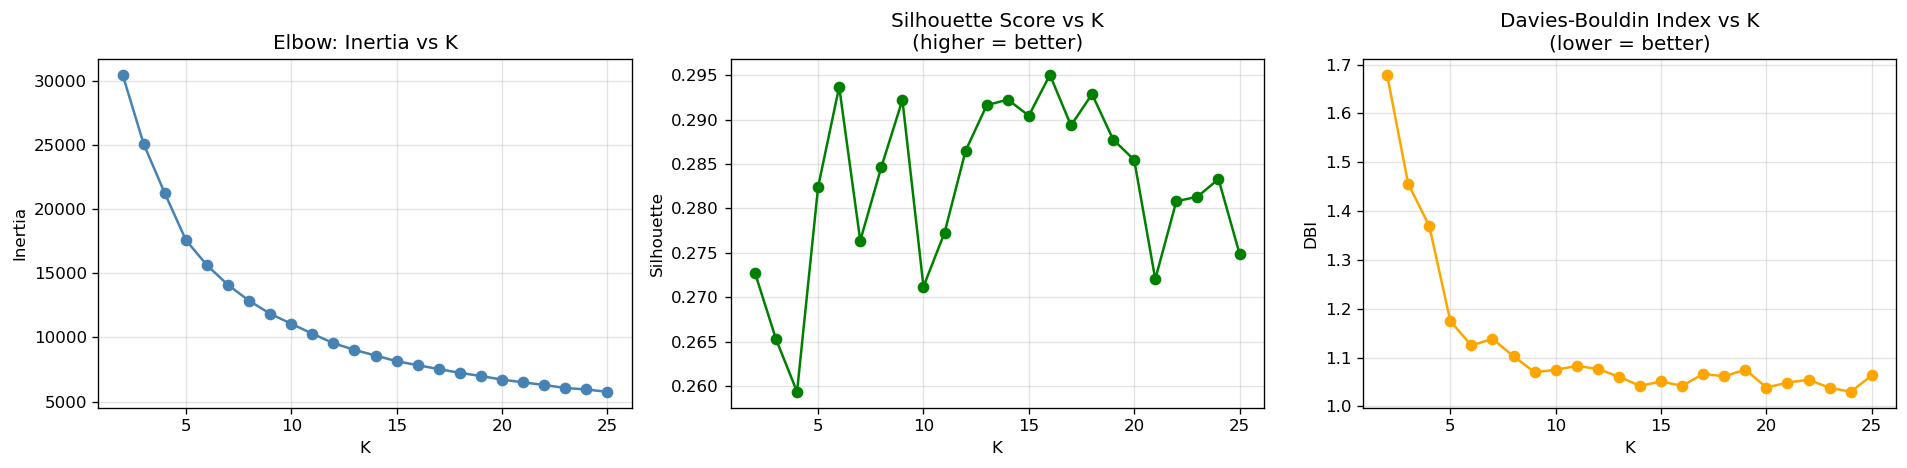

Auto-selected K = 16  (highest silhouette = 0.2950)
Override K below if the elbow plot suggests a different value


In [ ]:
k_range     = range(2, 26)
inertias    = []
silhouettes = []
dbi_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=RANDOM_STATE))
    dbi_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow: Inertia vs K")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.35)

axes[1].plot(k_range, silhouettes, marker="o", color="green")
axes[1].set_title("Silhouette Score vs K\n(higher = better)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
axes[1].grid(alpha=0.35)

axes[2].plot(k_range, dbi_scores, marker="o", color="orange")
axes[2].set_title("Davies-Bouldin Index vs K\n(lower = better)")
axes[2].set_xlabel("K"); axes[2].set_ylabel("DBI")
axes[2].grid(alpha=0.35)

plt.tight_layout()
plt.savefig("figures/kmeans_elbow.png", bbox_inches="tight")
plt.show()

K_BEST = silhouettes.index(max(silhouettes)) + 2  
print(f"Auto-selected K = {K_BEST}  (highest silhouette = {max(silhouettes):.4f})")
print("Override K below if the elbow plot suggests a different value")

## Run K-Means with Chosen K

In [5]:
K = K_BEST  

km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["kmeans_cluster"] = km.fit_predict(X)

sil_km  = silhouette_score(X, df["kmeans_cluster"], sample_size=min(5000, len(X)), random_state=RANDOM_STATE)
dbi_km  = davies_bouldin_score(X, df["kmeans_cluster"])
inertia = km.inertia_

print(f"K = {K}")
print(f"  Inertia          : {inertia:,.1f}")
print(f"  Silhouette score : {sil_km:.4f}  (target > 0.3)")
print(f"  Davies-Bouldin   : {dbi_km:.4f}  (lower is better)")

K = 16
  Inertia          : 7,838.1
  Silhouette score : 0.2950  (target > 0.3)
  Davies-Bouldin   : 1.0420  (lower is better)


## Cluster Size Distribution & Emissions Profile

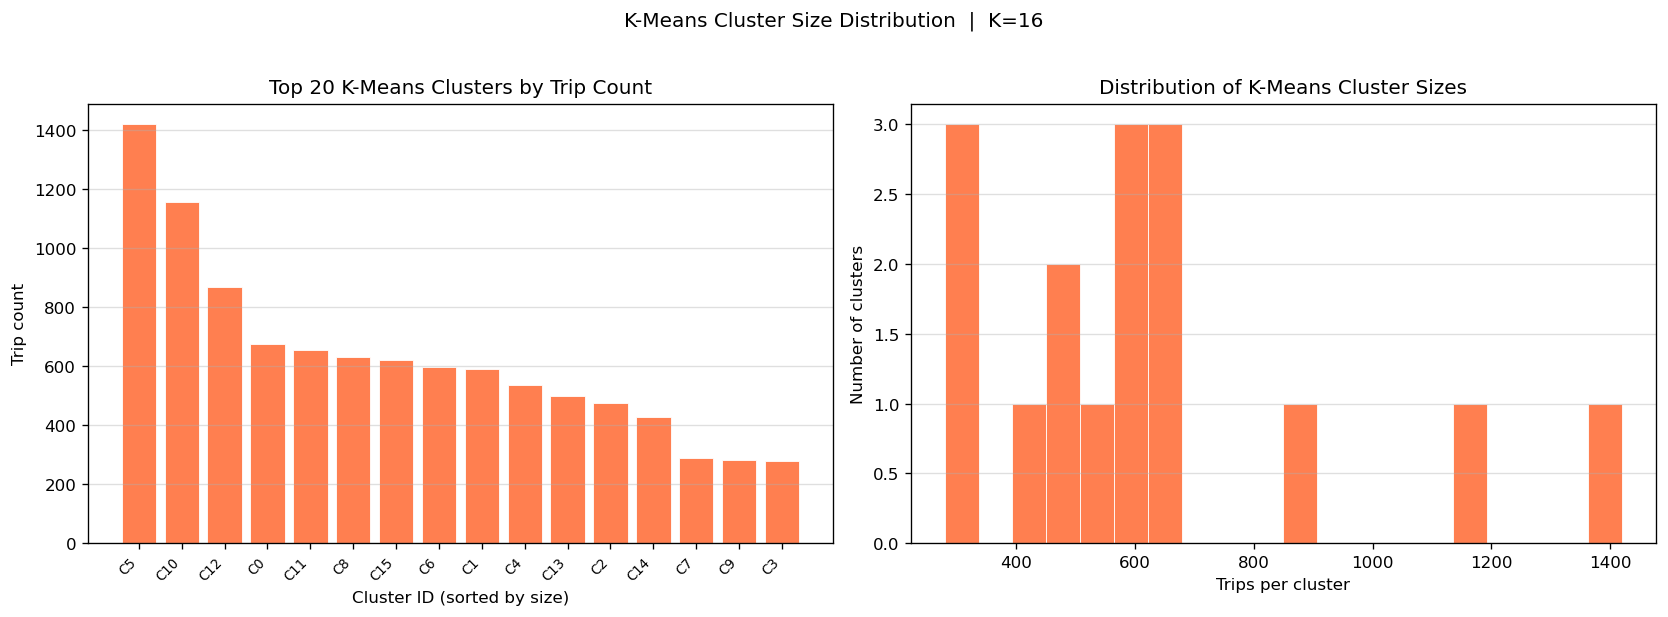

Median cluster size : 593 trips
Largest cluster     : 1420 trips
Smallest cluster    : 280 trips
Std dev of sizes    : 306.9  (lower = more balanced)


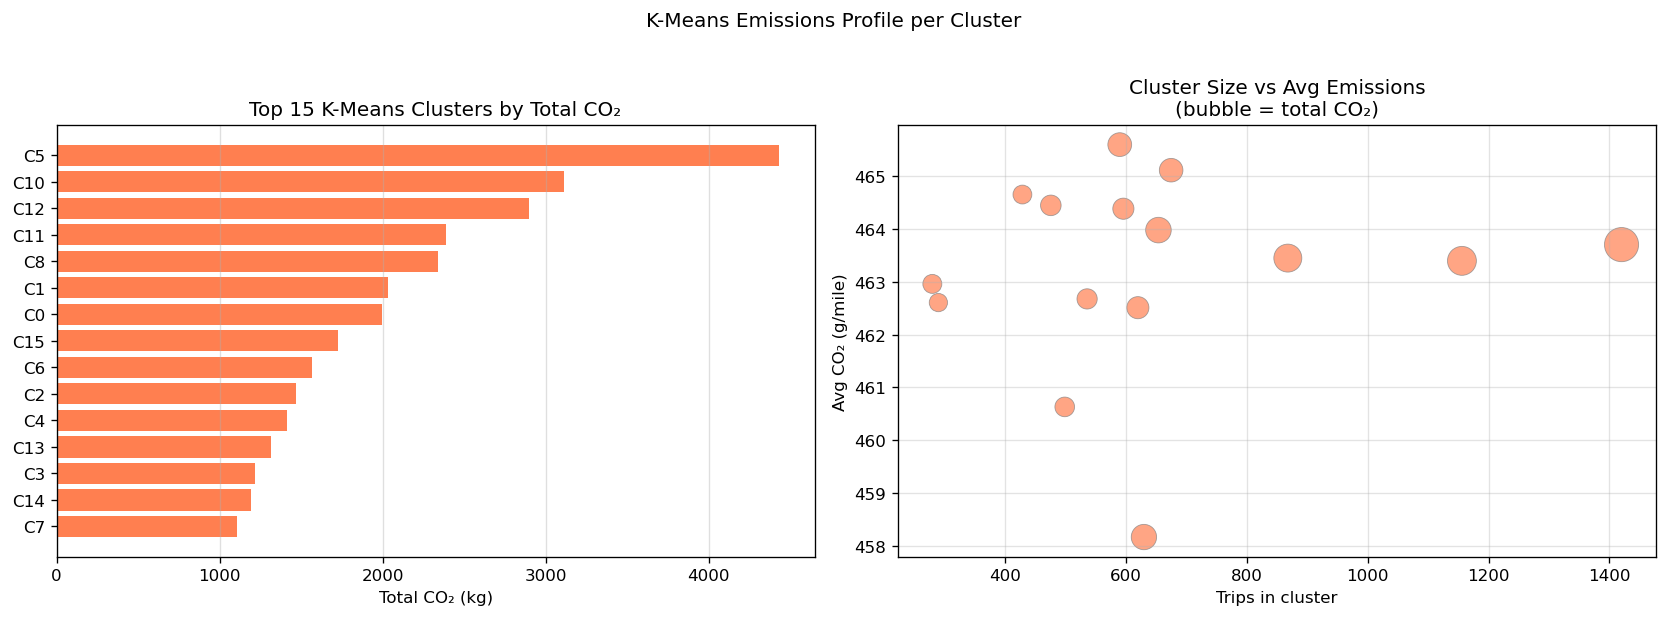


Top 5 highest-emission K-Means clusters:
 kmeans_cluster  n_trips  avg_co2_g_mi  total_co2_kg  avg_trip_miles
              5     1420    463.701081   4428.517631        6.713523
             10     1156    463.393751   3114.813828        5.814450
             12      868    463.445831   2897.717177        7.218609
             11      654    463.975531   2390.305057        7.842485
              8      630    458.167893   2338.643762        8.080041


In [ ]:
cluster_sizes = (
    df.groupby("kmeans_cluster").size()
    .reset_index(name="n_trips")
    .sort_values("n_trips", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-20 clusters by size
top20 = cluster_sizes.head(20)
axes[0].bar(top20.index, top20["n_trips"], color="coral", edgecolor="white", linewidth=0.5)
axes[0].set_xticks(top20.index)
axes[0].set_xticklabels([f"C{int(c)}" for c in top20["kmeans_cluster"]], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Cluster ID (sorted by size)")
axes[0].set_ylabel("Trip count")
axes[0].set_title("Top 20 K-Means Clusters by Trip Count")
axes[0].grid(axis="y", alpha=0.4)

# Histogram of all cluster sizes
axes[1].hist(cluster_sizes["n_trips"], bins=20, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Trips per cluster")
axes[1].set_ylabel("Number of clusters")
axes[1].set_title("Distribution of K-Means Cluster Sizes")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle(f"K-Means Cluster Size Distribution  |  K={K}", y=1.02)
plt.tight_layout()
plt.savefig("figures/kmeans_cluster_sizes.png", bbox_inches="tight")
plt.show()

print(f"Median cluster size : {cluster_sizes['n_trips'].median():.0f} trips")
print(f"Largest cluster     : {cluster_sizes['n_trips'].max()} trips")
print(f"Smallest cluster    : {cluster_sizes['n_trips'].min()} trips")
print(f"Std dev of sizes    : {cluster_sizes['n_trips'].std():.1f}  (lower = more balanced)")

# CO₂ emissions by cluster (top 15) 
emissions_km = (
    df.groupby("kmeans_cluster")
    .agg(
        n_trips        = ("trip_miles",     "count"),
        avg_co2_g_mi   = ("co2TailpipeGpm", "mean"),
        total_co2_kg   = ("co2_total_g",    lambda x: x.sum() / 1000),
        avg_trip_miles = ("trip_miles",     "mean"),
    )
    .reset_index()
    .sort_values("total_co2_kg", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(
    [f"C{int(r['kmeans_cluster'])}" for _, r in emissions_km.iterrows()],
    emissions_km["total_co2_kg"], color="coral"
)
axes[0].set_xlabel("Total CO₂ (kg)")
axes[0].set_title("Top 15 K-Means Clusters by Total CO₂")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.4)

axes[1].scatter(
    emissions_km["n_trips"], emissions_km["avg_co2_g_mi"],
    s=emissions_km["total_co2_kg"] / emissions_km["total_co2_kg"].max() * 400 + 20,
    color="coral", alpha=0.7, edgecolors="grey", linewidth=0.5
)
axes[1].set_xlabel("Trips in cluster")
axes[1].set_ylabel("Avg CO₂ (g/mile)")
axes[1].set_title("Cluster Size vs Avg Emissions\n(bubble = total CO₂)")
axes[1].grid(alpha=0.35)

plt.suptitle("K-Means Emissions Profile per Cluster", y=1.02)
plt.tight_layout()
plt.savefig("figures/kmeans_emissions_profile.png", bbox_inches="tight")
plt.show()

print("\nTop 5 highest-emission K-Means clusters:")
print(emissions_km[["kmeans_cluster","n_trips","avg_co2_g_mi","total_co2_kg","avg_trip_miles"]].head().to_string(index=False))

## Load DBSCAN Labels & Build Comparison Table

In [ ]:
dbscan_df = pd.read_csv("../Data/generated/trips_dbscan_labeled.csv")

dbscan_df["pickup_lat"]     = pd.to_numeric(dbscan_df["pickup_lat"],     errors="coerce")
dbscan_df["pickup_lon"]     = pd.to_numeric(dbscan_df["pickup_lon"],     errors="coerce")
dbscan_df["hour_sin"]       = pd.to_numeric(dbscan_df["hour_sin"],       errors="coerce")
dbscan_df["hour_cos"]       = pd.to_numeric(dbscan_df["hour_cos"],       errors="coerce")
dbscan_df["co2TailpipeGpm"] = pd.to_numeric(dbscan_df["co2TailpipeGpm"], errors="coerce")
dbscan_df["co2_total_g"]    = pd.to_numeric(dbscan_df["co2_total_g"],    errors="coerce")
dbscan_df["trip_miles"]     = pd.to_numeric(dbscan_df["trip_miles"],     errors="coerce")

dbscan_n_clusters = dbscan_df["dbscan_cluster"].nunique() - (1 if -1 in dbscan_df["dbscan_cluster"].values else 0)
dbscan_noise_pct  = (dbscan_df["dbscan_cluster"] == -1).mean() * 100

mask_db  = dbscan_df["dbscan_cluster"] != -1
X_db     = StandardScaler().fit_transform(
    dbscan_df.loc[mask_db, ["pickup_lat", "pickup_lon", "hour_sin", "hour_cos"]].values
)
sil_db   = silhouette_score(X_db, dbscan_df.loc[mask_db, "dbscan_cluster"],
                             sample_size=min(5000, mask_db.sum()), random_state=RANDOM_STATE)
dbi_db   = davies_bouldin_score(X_db, dbscan_df.loc[mask_db, "dbscan_cluster"])

comparison_df = pd.DataFrame([
    {
        "algorithm":      "DBSCAN",
        "n_clusters":      dbscan_n_clusters,
        "noise_pct":       round(dbscan_noise_pct, 1),
        "silhouette":      round(sil_db, 4),
        "davies_bouldin":  round(dbi_db, 4),
        "cluster_size_std": round(dbscan_df[dbscan_df["dbscan_cluster"]>=0].groupby("dbscan_cluster").size().std(), 1),
    },
    {
        "algorithm":      "K-Means",
        "n_clusters":      K,
        "noise_pct":       0.0,
        "silhouette":      round(sil_km, 4),
        "davies_bouldin":  round(dbi_km, 4),
        "cluster_size_std": round(cluster_sizes["n_trips"].std(), 1),
    },
])

print(comparison_df.to_string(index=False))
print("\nNotes:")
print("  silhouette    : higher is better (max 1.0)")
print("  davies_bouldin: lower is better")
print("  cluster_size_std: lower = more balanced cluster sizes")
print("  noise_pct     : DBSCAN labels outliers as noise; K-Means assigns all points")

algorithm  n_clusters  noise_pct  silhouette  davies_bouldin  cluster_size_std
   DBSCAN          80       15.8     -0.1192          2.1875             160.9
  K-Means          16        0.0      0.2950          1.0420             306.9

Notes:
  silhouette    : higher is better (max 1.0)
  davies_bouldin: lower is better
  cluster_size_std: lower = more balanced cluster sizes
  noise_pct     : DBSCAN labels outliers as noise; K-Means assigns all points


## Map Visualization

In [9]:
df.to_csv("../Data/trips_kmeans_labeled.csv", index=False)
comparison_df.to_csv("../Data/clustering_comparison.csv", index=False)
print(f"Saved trips_kmeans_labeled.csv ({len(df):,} rows)")
print("Saved clustering_comparison.csv")

Saved trips_kmeans_labeled.csv (10,000 rows)
Saved clustering_comparison.csv


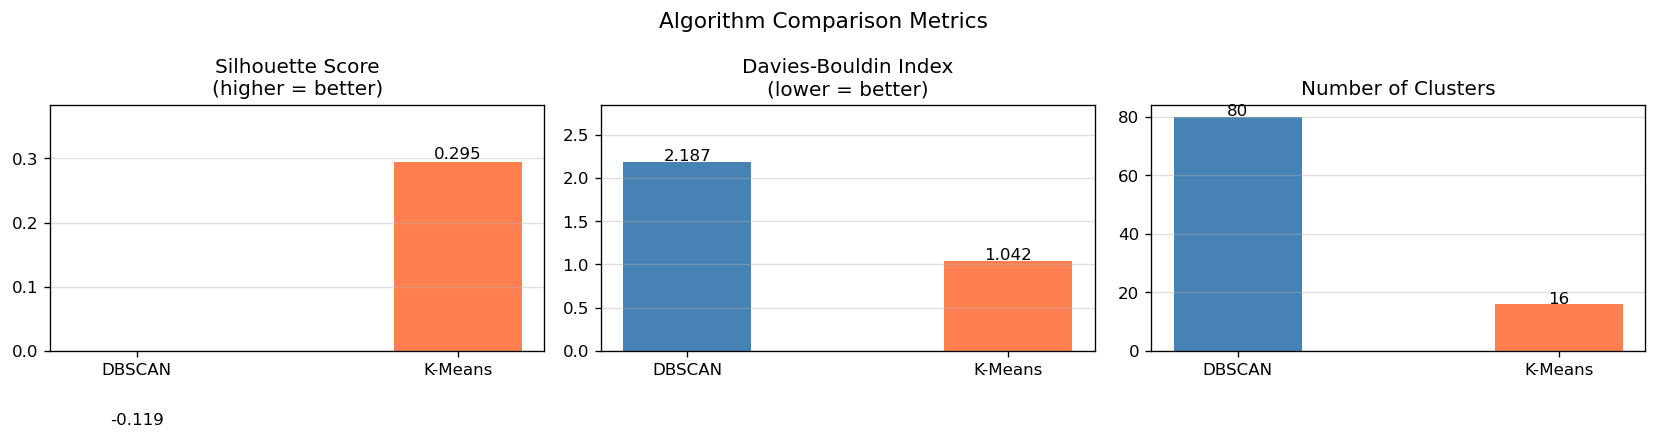

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

algos  = ["DBSCAN", "K-Means"]
colors = ["steelblue", "coral"]

# Silhouette
axes[0].bar(algos, [sil_db, sil_km], color=colors, width=0.4)
axes[0].set_title("Silhouette Score\n(higher = better)")
axes[0].set_ylim(0, max(sil_db, sil_km) * 1.3)
for i, v in enumerate([sil_db, sil_km]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center")
axes[0].grid(axis="y", alpha=0.4)

# Davies-Bouldin
axes[1].bar(algos, [dbi_db, dbi_km], color=colors, width=0.4)
axes[1].set_title("Davies-Bouldin Index\n(lower = better)")
axes[1].set_ylim(0, max(dbi_db, dbi_km) * 1.3)
for i, v in enumerate([dbi_db, dbi_km]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")
axes[1].grid(axis="y", alpha=0.4)

# Number of clusters
n_cl_db = dbscan_n_clusters
n_cl_km = K
axes[2].bar(algos, [n_cl_db, n_cl_km], color=colors, width=0.4)
axes[2].set_title("Number of Clusters")
for i, v in enumerate([n_cl_db, n_cl_km]):
    axes[2].text(i, v + 0.3, str(v), ha="center")
axes[2].grid(axis="y", alpha=0.4)

plt.suptitle("Algorithm Comparison Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("figures/algorithm_metrics_comparison.png", bbox_inches="tight")
plt.show()

In [11]:
df.to_csv("../Data/trips_kmeans_labeled.csv", index=False)
comparison_df.to_csv("../Data/clustering_comparison.csv", index=False)

print(f"Saved trips_kmeans_labeled.csv     ({len(df):,} rows, kmeans_cluster column added)")
print(f"Saved clustering_comparison.csv    ({len(comparison_df)} algorithms)")
print()
print(comparison_df.to_string(index=False))

Saved trips_kmeans_labeled.csv     (10,000 rows, kmeans_cluster column added)
Saved clustering_comparison.csv    (2 algorithms)

algorithm  n_clusters  noise_pct  silhouette  davies_bouldin  cluster_size_std
   DBSCAN          80       15.8     -0.1192          2.1875             160.9
  K-Means          16        0.0      0.2950          1.0420             306.9
